# Klasifikasi Teks Kebencanaan — Aspek & Emosi (5 Model + Optuna)

Pipeline modular (Google Colab, GPU-ready):

| Tahap | Isi |
|---|---|
| 1 | Data prep: cleaning, stratified split 80:20 (`random_state=42`) terpisah untuk **aspek** & **emosi** |
| 2 | 5 model + Optuna (Macro-F1 validasi, 15 trial/model): SVM+TF-IDF, 1D-CNN, BiLSTM, IndoBERT, Conv1D+BiLSTM |
| 3 | Evaluasi 20% test set, tabel perbandingan, pemilihan & penyimpanan Champion Model + Confusion Matrix |
| 4 | Inferensi batch pada baris populasi yang belum berlabel → `populasi_uts_final_terprediksi.csv` |
| 5 | Visualisasi distribusi prediksi & heatmap crosstab aspek × emosi |

**Cara pakai di Colab:** `Runtime > Change runtime type > GPU (T4)`, lalu jalankan sel dari atas ke bawah.
Studi Optuna disimpan di SQLite (`work/optuna.db`), sehingga jika sesi terputus, jalankan ulang sel yang sama dan proses **dilanjutkan**, bukan mengulang.
Ganti `QUICK_MODE` atau konfigurasi? Hapus folder `work/` dulu agar hasil lama tidak terpakai.

## 0. Instalasi dependensi

In [ ]:
# Colab sudah membawa torch, transformers, scikit-learn, pandas, matplotlib, seaborn, openpyxl.
# Yang perlu dipasang hanya optuna (+ openpyxl untuk jaga-jaga).
!pip -q install optuna openpyxl "transformers>=4.40" seaborn scikit-learn pandas matplotlib

## 1. Import & Konfigurasi
Semua pengaturan ada di `CFG`. Ubah `QUICK_MODE = True` untuk uji cepat (2 trial, epoch pendek) sebelum menjalankan penuh.

In [ ]:
import os, re, gc, io, json, time, copy, shutil, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import joblib

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

QUICK_MODE = False # True = uji cepat (n_trials=2, epoch pendek, BERT max_len 64)

CFG = dict(
    # --- berkas ---
    SAMPLE_FILE="sampel_anotasi_ABEC_final.xlsx",
    POP_FILE="populasi_uts_final.csv",
    OUTPUT_FILE="populasi_uts_final_kelarr.csv",
    WORK_DIR="work",                       # studi optuna, model, hasil
    # --- kolom ---
    TEXT_COL="komentar",
    ID_COL="id",
    TARGETS={"aspek": "aspek_final", "emosi": "emosi_final"},   # nama target -> kolom label
    DROP_LABELS=["Perlu Diskusi"],         # label belum final -> tidak dipakai untuk latih/uji
    # --- split & tuning ---
    SEED=42,
    TEST_SIZE=0.20,
    VAL_SIZE=0.20,                         # porsi validasi dari train (untuk Optuna)
    N_TRIALS=15,
    # --- model token (CNN / BiLSTM / Hybrid) ---
    MAX_LEN=200, EMB_DIM=128, MAX_VOCAB=20000, MIN_FREQ=2,
    DL_BATCH=32, DL_MAX_EPOCHS=40, DL_PATIENCE=6,
    # --- IndoBERT ---
    BERT_NAME="indobenchmark/indobert-base-p1",
    BERT_MAX_LEN=256, BERT_MAX_EPOCHS=10, BERT_PATIENCE=3, BERT_BATCH_CHOICES=[8, 16, 32],
)
if QUICK_MODE:
    CFG.update(N_TRIALS=2, DL_MAX_EPOCHS=4, DL_PATIENCE=2, BERT_MAX_LEN=64,
               BERT_MAX_EPOCHS=2, BERT_PATIENCE=1, BERT_BATCH_CHOICES=[16])

MODEL_KEYS = ["svm", "cnn", "bilstm", "bert", "hybrid"]
MODEL_NAMES = {"svm": "SVM + TF-IDF", "cnn": "1D-CNN", "bilstm": "BiLSTM",
               "bert": "IndoBERT", "hybrid": "Conv1D + BiLSTM"}

def set_seed(seed=CFG["SEED"]):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
WORK = Path(CFG["WORK_DIR"]); (WORK / "models").mkdir(parents=True, exist_ok=True)
(WORK / "results").mkdir(exist_ok=True); (WORK / "figures").mkdir(exist_ok=True)
print("Device:", DEVICE, "|", torch.cuda.get_device_name(0) if USE_AMP else "CPU (lambat untuk IndoBERT)")

Device: cuda | Tesla T4


## 2. Memuat Data
Jika berkas belum ada di folder kerja (mis. di Colab), sel ini meminta upload.

In [ ]:
def ensure_files(names):
    missing = [n for n in names if not Path(n).exists()]
    if not missing:
        return
    try:
        from google.colab import files   # hanya ada di Colab
        print("Upload berkas:", missing)
        files.upload()
    except ImportError:
        raise FileNotFoundError(f"Berkas tidak ditemukan: {missing}")

ensure_files([CFG["SAMPLE_FILE"], CFG["POP_FILE"]])
df_sample = pd.read_excel(CFG["SAMPLE_FILE"])
df_pop = pd.read_csv(CFG["POP_FILE"])
print("Sampel:", df_sample.shape, "| Populasi:", df_pop.shape)
print("ID sampel yang ada di populasi:", df_sample[CFG["ID_COL"]].isin(df_pop[CFG["ID_COL"]]).sum())
for t, col in CFG["TARGETS"].items():
    print(f"\nDistribusi {col}:\n{df_sample[col].value_counts().to_string()}")

Sampel: (340, 12) | Populasi: (2890, 10)
ID sampel yang ada di populasi: 340

Distribusi aspek_final:
aspek_final
A5               216
A8                28
A1                25
A7                21
A9                12
A3                11
Perlu Diskusi     10
A4                 9
A6                 5
A2                 3

Distribusi emosi_final:
emosi_final
Neutral          211
Anger             42
Joy               29
Sadness           26
Disgust           24
Fear               4
Perlu Diskusi      4


## 3. Data Prep
* Cleaning: case folding → hapus URL → hapus mention → hapus non-alfanumerik → rapikan spasi.
* Label `Perlu Diskusi` (belum disepakati rater) **dikeluarkan** dari pelatihan/pengujian, per target.
* Split stratified 80:20 (`random_state=42`) dilakukan **terpisah** untuk aspek dan emosi.

In [ ]:
URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
MENTION_RE = re.compile(r"@\w+")
NONALNUM_RE = re.compile(r"[^a-z0-9\s]")
WS_RE = re.compile(r"\s+")

def clean_text(text) -> str:
    text = str(text).lower()                 # case folding
    text = URL_RE.sub(" ", text)             # URL
    text = MENTION_RE.sub(" ", text)         # mention
    text = NONALNUM_RE.sub(" ", text)        # non-alfanumerik (hashtag -> kata, emoji/tanda baca dibuang)
    return WS_RE.sub(" ", text).strip()      # whitespace

def make_split(df, target_col):
    """Return dict berisi split train/test untuk satu target + label encoder."""
    d = df[~df[target_col].isin(CFG["DROP_LABELS"])].dropna(subset=[target_col, CFG["TEXT_COL"]]).copy()
    d["clean"] = d[CFG["TEXT_COL"]].map(clean_text)
    le = LabelEncoder().fit(d[target_col])
    y = le.transform(d[target_col])
    idx_tr, idx_te = train_test_split(np.arange(len(d)), test_size=CFG["TEST_SIZE"],
                                      stratify=y, random_state=CFG["SEED"])
    return dict(le=le, X_train=d["clean"].values[idx_tr], y_train=y[idx_tr],
                X_test=d["clean"].values[idx_te], y_test=y[idx_te],
                ids_train=d[CFG["ID_COL"]].values[idx_tr], ids_test=d[CFG["ID_COL"]].values[idx_te],
                n_total=len(d))

def inner_val_split(X, y):
    """Split validasi dari train untuk Optuna (stratified; fallback non-stratified bila kelas terlalu kecil)."""
    idx = np.arange(len(X))
    try:
        a, b = train_test_split(idx, test_size=CFG["VAL_SIZE"], stratify=y, random_state=CFG["SEED"])
    except ValueError:
        a, b = train_test_split(idx, test_size=CFG["VAL_SIZE"], random_state=CFG["SEED"])
    return X[a], y[a], X[b], y[b]

DATA = {t: make_split(df_sample, col) for t, col in CFG["TARGETS"].items()}
for t, d in DATA.items():
    print(f"[{t}] total={d['n_total']} train={len(d['y_train'])} test={len(d['y_test'])} "
          f"kelas={list(d['le'].classes_)}")
    print("   test per kelas:", dict(zip(d["le"].classes_, np.bincount(d["y_test"], minlength=len(d["le"].classes_)))))
print("\nContoh cleaning:\n", df_sample[CFG["TEXT_COL"]].iloc[1][:200], "\n->", clean_text(df_sample[CFG["TEXT_COL"]].iloc[1])[:200])

[aspek] total=330 train=264 test=66 kelas=['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9']
   test per kelas: {'A1': np.int64(5), 'A2': np.int64(1), 'A3': np.int64(2), 'A4': np.int64(2), 'A5': np.int64(43), 'A6': np.int64(1), 'A7': np.int64(4), 'A8': np.int64(6), 'A9': np.int64(2)}
[emosi] total=336 train=268 test=68 kelas=['Anger', 'Disgust', 'Fear', 'Joy', 'Neutral', 'Sadness']
   test per kelas: {'Anger': np.int64(8), 'Disgust': np.int64(5), 'Fear': np.int64(1), 'Joy': np.int64(6), 'Neutral': np.int64(43), 'Sadness': np.int64(5)}

Contoh cleaning:
 Presiden Prabowo Subianto memastikan pemerintah segera mengirim bantuan motor trail ke Jambi untuk mendukung mobilitas petugas dalam menangani kebakaran hutan dan lahan (karhutla).

"Anda punya 81 pos 
-> presiden prabowo subianto memastikan pemerintah segera mengirim bantuan motor trail ke jambi untuk mendukung mobilitas petugas dalam menangani kebakaran hutan dan lahan karhutla anda punya 81 pos kita


## 4. Metrik & Utilitas

In [ ]:
def compute_metrics(y_true, y_pred):
    return dict(
        accuracy=accuracy_score(y_true, y_pred),
        precision_macro=precision_score(y_true, y_pred, average="macro", zero_division=0),
        recall_macro=recall_score(y_true, y_pred, average="macro", zero_division=0),
        f1_macro=f1_score(y_true, y_pred, average="macro", zero_division=0),
    )

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 5. Model 1 — SVM + TF-IDF (baseline)

In [ ]:
class SVMClassifier:
    kind = "sklearn"

    def __init__(self, n_classes, params=None):
        self.n_classes, self.params = n_classes, params or {}
        self.pipe = None

    def fit(self, X, y, X_val=None, y_val=None, epochs=None):
        p = self.params
        self.pipe = Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=1)),
            ("svm", SVC(C=p.get("C", 1.0), kernel=p.get("kernel", "linear"),
                        class_weight="balanced", random_state=CFG["SEED"])),
        ]).fit(X, y)
        info = {"best_epoch": None}
        if X_val is not None:
            info["val_f1"] = macro_f1(y_val, self.predict(X_val))
        return info

    def predict(self, X):
        return self.pipe.predict(list(X))

    def save(self, path):
        path = Path(path); path.mkdir(parents=True, exist_ok=True)
        joblib.dump(self.pipe, path / "pipe.joblib")
        json.dump(dict(kind=self.kind, arch="svm", n_classes=self.n_classes, params=self.params),
                  open(path / "meta.json", "w"))

    @classmethod
    def load(cls, path):
        path = Path(path); meta = json.load(open(path / "meta.json"))
        obj = cls(meta["n_classes"], meta["params"]); obj.pipe = joblib.load(path / "pipe.joblib")
        return obj

## 6. Model 2–5 — Arsitektur PyTorch
* **CNN**: Embedding → Conv1D(kernel_size) → global max-pool → Dense
* **BiLSTM**: Embedding → BiLSTM (packed sequence) → masked max-pool → Dense
* **Hybrid**: Embedding → Conv1D(k=3) → BiLSTM → masked max-pool → Dense
* **IndoBERT**: `AutoModelForSequenceClassification` (fine-tuning penuh, mixed precision di GPU)

In [ ]:
def masked_max_pool(x, mask):
    """x: (B,T,H), mask: (B,T) bool -> (B,H)."""
    return x.masked_fill(~mask.unsqueeze(-1), -1e4).max(dim=1).values

class CNNText(nn.Module):
    def __init__(self, vocab_size, n_classes, emb_dim, filters, kernel_size, dropout):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.conv = nn.Conv1d(emb_dim, filters, kernel_size, padding=kernel_size // 2)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(filters, n_classes)

    def forward(self, input_ids, attention_mask):
        x = self.drop(self.emb(input_ids))                       # B,T,E
        h = torch.relu(self.conv(x.transpose(1, 2))).transpose(1, 2)[:, :input_ids.size(1)]
        return self.fc(self.drop(masked_max_pool(h, attention_mask.bool())))

def run_lstm(lstm, x, mask):
    lengths = mask.sum(1).clamp(min=1).cpu()
    packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
    out, _ = lstm(packed)
    out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
    return out

class BiLSTMText(nn.Module):
    def __init__(self, vocab_size, n_classes, emb_dim, hidden_units, dropout):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_units, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * hidden_units, n_classes)

    def forward(self, input_ids, attention_mask):
        x = self.drop(self.emb(input_ids))
        out = run_lstm(self.lstm, x, attention_mask)
        return self.fc(self.drop(masked_max_pool(out, attention_mask.bool())))

class HybridText(nn.Module):
    def __init__(self, vocab_size, n_classes, emb_dim, filters, lstm_units, dropout, kernel_size=3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.conv = nn.Conv1d(emb_dim, filters, kernel_size, padding=kernel_size // 2)
        self.lstm = nn.LSTM(filters, lstm_units, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * lstm_units, n_classes)

    def forward(self, input_ids, attention_mask):
        x = self.drop(self.emb(input_ids))
        h = torch.relu(self.conv(x.transpose(1, 2))).transpose(1, 2)[:, :input_ids.size(1)]
        h = self.drop(h)
        out = run_lstm(self.lstm, h, attention_mask)
        return self.fc(self.drop(masked_max_pool(out, attention_mask.bool())))

class Vocab:
    """Vocabulary word-level, dibangun HANYA dari data latih (tanpa kebocoran)."""
    PAD, UNK = 0, 1
    def __init__(self, stoi=None): self.stoi = stoi or {}
    @classmethod
    def build(cls, texts, min_freq, max_size):
        from collections import Counter
        cnt = Counter(w for t in texts for w in t.split())
        words = [w for w, c in cnt.most_common(max_size) if c >= min_freq]
        return cls({w: i + 2 for i, w in enumerate(words)})
    def __len__(self): return len(self.stoi) + 2
    def encode(self, texts, max_len):
        ids = np.zeros((len(texts), max_len), dtype=np.int64)
        for i, t in enumerate(texts):
            toks = [self.stoi.get(w, self.UNK) for w in t.split()][:max_len]
            ids[i, :len(toks)] = toks
        return torch.from_numpy(ids)

class EncodedDataset(Dataset):
    def __init__(self, enc: dict, y=None):
        self.enc, self.y = enc, y
    def __len__(self): return len(next(iter(self.enc.values())))
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        if self.y is not None: item["labels"] = torch.tensor(self.y[i], dtype=torch.long)
        return item

def class_weights(y, n_classes):
    """Bobot kelas 'balanced' yang dilunakkan (akar) agar kelas sangat kecil tidak membuat training tidak stabil."""
    counts = np.bincount(y, minlength=n_classes).astype(float)
    w = np.where(counts > 0, (len(y) / (n_classes * np.maximum(counts, 1))) ** 0.5, 1.0)
    return torch.tensor(w, dtype=torch.float)

### Wrapper generik untuk semua model PyTorch (CNN / BiLSTM / Hybrid / IndoBERT)

In [ ]:
class TorchTextClassifier:
    kind = "torch"

    def __init__(self, arch, n_classes, params=None):
        assert arch in ("cnn", "bilstm", "hybrid", "bert")
        self.arch, self.n_classes, self.params = arch, n_classes, params or {}
        self.model, self.vocab, self.tokenizer = None, None, None
        self.max_len = CFG["BERT_MAX_LEN"] if arch == "bert" else CFG["MAX_LEN"]

    # ---------- encoding ----------
    def _encode(self, texts):
        texts = [str(t) for t in texts]
        if self.arch == "bert":
            enc = self.tokenizer(texts, truncation=True, max_length=self.max_len,
                                 padding=True, return_tensors="pt")
            return {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"]}
        ids = self.vocab.encode(texts, self.max_len)
        return {"input_ids": ids, "attention_mask": (ids != Vocab.PAD).long()}

    # ---------- model ----------
    def _build_model(self):
        p, K = self.params, self.n_classes
        if self.arch == "cnn":
            return CNNText(len(self.vocab), K, CFG["EMB_DIM"], p["filters"], p["kernel_size"], p["dropout"])
        if self.arch == "bilstm":
            return BiLSTMText(len(self.vocab), K, CFG["EMB_DIM"], p["hidden_units"], p["dropout"])
        if self.arch == "hybrid":
            return HybridText(len(self.vocab), K, CFG["EMB_DIM"], p["filters"], p["lstm_units"], p["dropout"])
        from transformers import AutoModelForSequenceClassification
        return AutoModelForSequenceClassification.from_pretrained(CFG["BERT_NAME"], num_labels=K)

    def _forward(self, batch):
        ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
        if self.arch == "bert":
            return self.model(input_ids=ids, attention_mask=mask).logits
        return self.model(ids, mask)

    # ---------- training ----------
    def fit(self, X, y, X_val=None, y_val=None, epochs=None):
        """Dengan validasi: early stopping (Macro-F1) & kembalikan best_epoch.
        Tanpa validasi: latih persis `epochs` epoch (refit pada seluruh train)."""
        set_seed()
        p, is_bert = self.params, self.arch == "bert"
        max_epochs = epochs or (CFG["BERT_MAX_EPOCHS"] if is_bert else CFG["DL_MAX_EPOCHS"])
        patience = CFG["BERT_PATIENCE"] if is_bert else CFG["DL_PATIENCE"]
        batch_size = p.get("batch_size", CFG["DL_BATCH"])

        if is_bert:
            from transformers import AutoTokenizer, get_linear_schedule_with_warmup
            self.tokenizer = AutoTokenizer.from_pretrained(CFG["BERT_NAME"])
        else:
            self.vocab = Vocab.build(X, CFG["MIN_FREQ"], CFG["MAX_VOCAB"])
        self.model = self._build_model().to(DEVICE)

        train_dl = DataLoader(EncodedDataset(self._encode(X), y), batch_size=batch_size, shuffle=True)
        opt = torch.optim.AdamW(self.model.parameters(), lr=p["lr"], weight_decay=0.01)
        sched = None
        if is_bert:
            total = max_epochs * len(train_dl)
            sched = get_linear_schedule_with_warmup(opt, int(0.1 * total), total)
        loss_fn = nn.CrossEntropyLoss(weight=class_weights(y, self.n_classes).to(DEVICE))
        scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

        best_f1, best_epoch, best_state, bad = -1.0, max_epochs, None, 0
        for epoch in range(1, max_epochs + 1):
            self.model.train()
            for batch in train_dl:
                opt.zero_grad(set_to_none=True)
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                    loss = loss_fn(self._forward(batch).float(), batch["labels"].to(DEVICE))
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                scaler.step(opt); scaler.update()
                if sched: sched.step()
            if X_val is None:
                continue
            f1 = macro_f1(y_val, self.predict(X_val))
            if f1 > best_f1:
                best_f1, best_epoch, bad = f1, epoch, 0
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
            else:
                bad += 1
                if bad >= patience: break
        if X_val is not None and best_state is not None:
            self.model.load_state_dict(best_state)
        return {"best_epoch": best_epoch, "val_f1": best_f1 if X_val is not None else None}

    # ---------- inference ----------
    @torch.no_grad()
    def predict(self, X, batch_size=64):
        self.model.eval()
        X = list(X); preds = []
        for i in range(0, len(X), batch_size):
            batch = self._encode(X[i:i + batch_size])
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                logits = self._forward(batch)
            preds.append(logits.argmax(-1).cpu().numpy())
        return np.concatenate(preds) if preds else np.array([], dtype=int)

    # ---------- persistence ----------
    def save(self, path):
        path = Path(path); path.mkdir(parents=True, exist_ok=True)
        meta = dict(kind=self.kind, arch=self.arch, n_classes=self.n_classes, params=self.params)
        if self.arch == "bert":
            self.model.save_pretrained(path / "hf"); self.tokenizer.save_pretrained(path / "hf")
        else:
            torch.save(self.model.state_dict(), path / "weights.pt")
            json.dump(self.vocab.stoi, open(path / "vocab.json", "w"))
        json.dump(meta, open(path / "meta.json", "w"))

    @classmethod
    def load(cls, path):
        path = Path(path); meta = json.load(open(path / "meta.json"))
        obj = cls(meta["arch"], meta["n_classes"], meta["params"])
        if obj.arch == "bert":
            from transformers import AutoTokenizer, AutoModelForSequenceClassification
            obj.tokenizer = AutoTokenizer.from_pretrained(path / "hf")
            obj.model = AutoModelForSequenceClassification.from_pretrained(path / "hf")
        else:
            obj.vocab = Vocab(json.load(open(path / "vocab.json")))
            obj.model = obj._build_model()
            obj.model.load_state_dict(torch.load(path / "weights.pt", map_location="cpu"))
        obj.model.to(DEVICE).eval()
        return obj

def load_any_model(path):
    kind = json.load(open(Path(path) / "meta.json"))["kind"]
    return (SVMClassifier if kind == "sklearn" else TorchTextClassifier).load(path)

def build_model(key, n_classes, params):
    return SVMClassifier(n_classes, params) if key == "svm" else TorchTextClassifier(key, n_classes, params)

## 7. Ruang Pencarian Optuna
Sesuai spesifikasi; hyperparameter selain itu dibuat tetap (lihat `CFG`).

In [ ]:
def suggest_params(key, trial):
    if key == "svm":
        return dict(C=trial.suggest_float("C", 1e-2, 1e2, log=True),
                    kernel=trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"]))
    if key == "cnn":
        return dict(filters=trial.suggest_categorical("filters", [64, 128, 256]),
                    kernel_size=trial.suggest_categorical("kernel_size", [2, 3, 4, 5]),
                    dropout=trial.suggest_float("dropout", 0.1, 0.6),
                    lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True))
    if key == "bilstm":
        return dict(hidden_units=trial.suggest_categorical("hidden_units", [64, 128, 256]),
                    dropout=trial.suggest_float("dropout", 0.1, 0.6),
                    lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True))
    if key == "bert":
        return dict(lr=trial.suggest_float("lr", 2e-5, 5e-5, log=True),
                    batch_size=trial.suggest_categorical("batch_size", CFG["BERT_BATCH_CHOICES"]))
    if key == "hybrid":
        return dict(filters=trial.suggest_categorical("filters", [64, 128, 256]),
                    lstm_units=trial.suggest_categorical("lstm_units", [64, 128, 256]),
                    dropout=trial.suggest_float("dropout", 0.1, 0.6),
                    lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True))
    raise ValueError(key)

def make_objective(key, X_tr, y_tr, X_va, y_va, n_classes):
    def objective(trial):
        params = suggest_params(key, trial)
        model = build_model(key, n_classes, params)
        info = model.fit(X_tr, y_tr, X_va, y_va)
        trial.set_user_attr("best_epoch", info["best_epoch"])
        del model; free_memory()
        return info["val_f1"]
    return objective

## 8. Tuning → Refit → Evaluasi (semua model × kedua target)
Alur per model & target:
1. Optuna (15 trial, maksimalkan **Macro-F1 validasi**) pada split train-dalam/validasi (80/20 dari train).
2. Refit dengan hyperparameter terbaik pada **seluruh train** (DL: jumlah epoch = `best_epoch` trial terbaik).
3. Evaluasi pada 20% **test set**; model & metrik disimpan (proses dapat dilanjutkan).

In [ ]:
STORAGE = f"sqlite:///{(WORK / 'optuna.db').as_posix()}"

def run_model(target, key):
    d = DATA[target]; K = len(d["le"].classes_)
    res_path = WORK / "results" / f"{target}_{key}.json"
    model_dir = WORK / "models" / target / key
    if res_path.exists() and model_dir.exists():
        return json.load(open(res_path))

    X_tr, y_tr, X_va, y_va = inner_val_split(d["X_train"], d["y_train"])
    study = optuna.create_study(direction="maximize", study_name=f"{target}_{key}", storage=STORAGE,
                                load_if_exists=True, sampler=optuna.samplers.TPESampler(seed=CFG["SEED"]))
    done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    t0 = time.time()
    if done < CFG["N_TRIALS"]:
        study.optimize(make_objective(key, X_tr, y_tr, X_va, y_va, K), n_trials=CFG["N_TRIALS"] - done)
    tune_time = time.time() - t0

    best = study.best_trial
    params, best_epoch = dict(best.params), best.user_attrs.get("best_epoch")
    t0 = time.time()
    model = build_model(key, K, params)
    model.fit(d["X_train"], d["y_train"], epochs=best_epoch)       # refit pada seluruh train
    fit_time = time.time() - t0
    y_pred = model.predict(d["X_test"])
    model.save(model_dir)

    res = dict(target=target, model_key=key, model=MODEL_NAMES[key], best_params=params,
               best_epoch=best_epoch, val_f1_macro=best.value, n_trials=len(study.trials),
               tune_seconds=round(tune_time, 1), refit_seconds=round(fit_time, 1),
               y_pred=[int(v) for v in y_pred], **compute_metrics(d["y_test"], y_pred))
    json.dump(res, open(res_path, "w"), indent=2)
    del model; free_memory()
    return res

RESULTS = {}
for target in CFG["TARGETS"]:
    for key in MODEL_KEYS:
        t0 = time.time()
        RESULTS[(target, key)] = run_model(target, key)
        r = RESULTS[(target, key)]
        print(f"[{target:5s}] {MODEL_NAMES[key]:16s} val_F1={r['val_f1_macro']:.3f} | "
              f"test Acc={r['accuracy']:.3f} F1={r['f1_macro']:.3f} | {time.time()-t0:6.0f}s | {r['best_params']}")

[aspek] SVM + TF-IDF     val_F1=0.314 | test Acc=0.682 F1=0.255 |      0s | {'C': 1.1681739205310986, 'kernel': 'sigmoid'}
[aspek] 1D-CNN           val_F1=0.272 | test Acc=0.667 F1=0.227 |      0s | {'filters': 128, 'kernel_size': 3, 'dropout': 0.15793452976256486, 'lr': 0.005323617594751502}
[aspek] BiLSTM           val_F1=0.365 | test Acc=0.697 F1=0.311 |      0s | {'hidden_units': 256, 'dropout': 0.19637023271546566, 'lr': 0.004122444467482721}
[aspek] IndoBERT         val_F1=0.406 | test Acc=0.682 F1=0.359 |      0s | {'lr': 4.597060299725434e-05, 'batch_size': 16}
[aspek] Conv1D + BiLSTM  val_F1=0.276 | test Acc=0.561 F1=0.127 |      0s | {'filters': 128, 'lstm_units': 64, 'dropout': 0.26437168065710037, 'lr': 0.009328769366522743}
[emosi] SVM + TF-IDF     val_F1=0.488 | test Acc=0.662 F1=0.300 |      0s | {'C': 0.7461044222778568, 'kernel': 'sigmoid'}
[emosi] 1D-CNN           val_F1=0.400 | test Acc=0.368 F1=0.221 |      0s | {'filters': 256, 'kernel_size': 4, 'dropout': 0.115534

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[emosi] IndoBERT         val_F1=0.675 | test Acc=0.735 F1=0.384 |    194s | {'lr': 3.087757774489208e-05, 'batch_size': 16}
[emosi] Conv1D + BiLSTM  val_F1=0.373 | test Acc=0.706 F1=0.343 |     52s | {'filters': 128, 'lstm_units': 64, 'dropout': 0.27754862877713543, 'lr': 0.007722692731209381}


## 9. Tabel Perbandingan Performa (20% Test Set)

In [ ]:
rows = []
for (target, key), r in RESULTS.items():
    rows.append(dict(Target=target.capitalize(), Model=r["model"], Accuracy=r["accuracy"],
                     Macro_Precision=r["precision_macro"], Macro_Recall=r["recall_macro"],
                     Macro_F1=r["f1_macro"], Val_Macro_F1=r["val_f1_macro"]))
df_cmp = pd.DataFrame(rows)
df_cmp.to_csv(WORK / "results" / "perbandingan_model.csv", index=False)
for target in CFG["TARGETS"]:
    print(f"\n=== Perbandingan model — {target.upper()} (n_test={len(DATA[target]['y_test'])}) ===")
    tbl = df_cmp[df_cmp.Target == target.capitalize()].drop(columns="Target").sort_values("Macro_F1", ascending=False)
    try:
        display(tbl.style.format({c: "{:.4f}" for c in tbl.columns if c != "Model"})
                   .highlight_max(subset=["Accuracy", "Macro_Precision", "Macro_Recall", "Macro_F1"], color="#cfe8ff")
                   .hide(axis="index"))
    except NameError:                       # di luar Jupyter
        print(tbl.round(4).to_string(index=False))


=== Perbandingan model — ASPEK (n_test=66) ===


Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Val_Macro_F1
IndoBERT,0.6818,0.3744,0.3815,0.3589,0.4061
BiLSTM,0.6970,0.3094,0.3182,0.3107,0.3647
SVM + TF-IDF,0.6818,0.2356,0.2837,0.2554,0.3138
1D-CNN,0.6667,0.2180,0.2419,0.2273,0.2724
Conv1D + BiLSTM,0.5606,0.1198,0.1349,0.1268,0.2756



=== Perbandingan model — EMOSI (n_test=68) ===


Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Val_Macro_F1
IndoBERT,0.7353,0.4400,0.3978,0.3840,0.6752
Conv1D + BiLSTM,0.7059,0.3598,0.3550,0.3426,0.3730
SVM + TF-IDF,0.6618,0.2943,0.3240,0.3005,0.4881
BiLSTM,0.7059,0.3000,0.3286,0.2896,0.4626
1D-CNN,0.3676,0.2872,0.2984,0.2212,0.4005


## 10. Champion Model & Confusion Matrix
Champion dipilih **per target** berdasarkan Macro-F1 test (tie-break: Accuracy). Model disalin ke `work/models/champion_<target>/`.

> Catatan: test set kecil (±66–68 baris) dan beberapa kelas hanya punya 1 contoh uji, sehingga selisih F1 antar model yang kecil belum tentu signifikan.

Champion aspek: IndoBERT (Macro-F1 test=0.3589) -> work/models/champion_aspek
Champion emosi: IndoBERT (Macro-F1 test=0.3840) -> work/models/champion_emosi


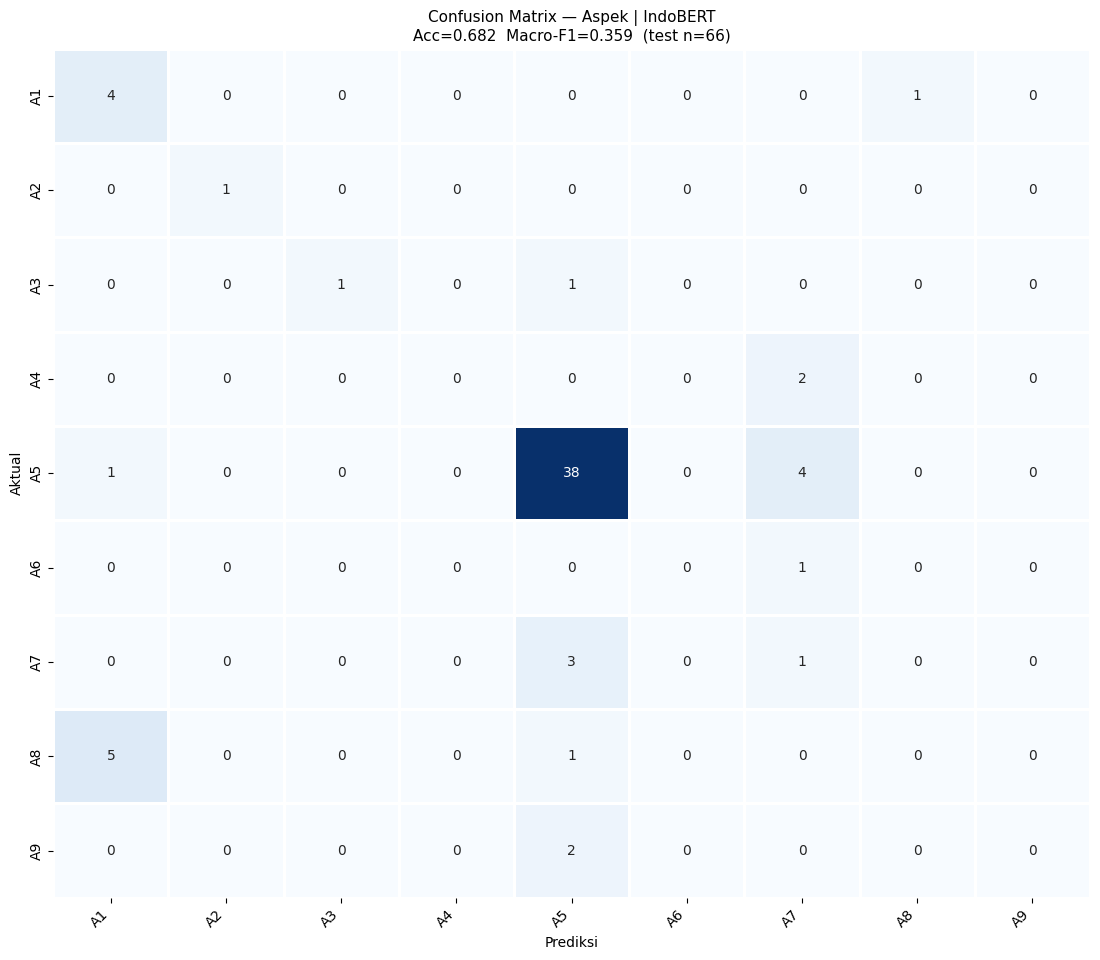

              precision    recall  f1-score   support

          A1       0.40      0.80      0.53         5
          A2       1.00      1.00      1.00         1
          A3       1.00      0.50      0.67         2
          A4       0.00      0.00      0.00         2
          A5       0.84      0.88      0.86        43
          A6       0.00      0.00      0.00         1
          A7       0.12      0.25      0.17         4
          A8       0.00      0.00      0.00         6
          A9       0.00      0.00      0.00         2

    accuracy                           0.68        66
   macro avg       0.37      0.38      0.36        66
weighted avg       0.63      0.68      0.65        66



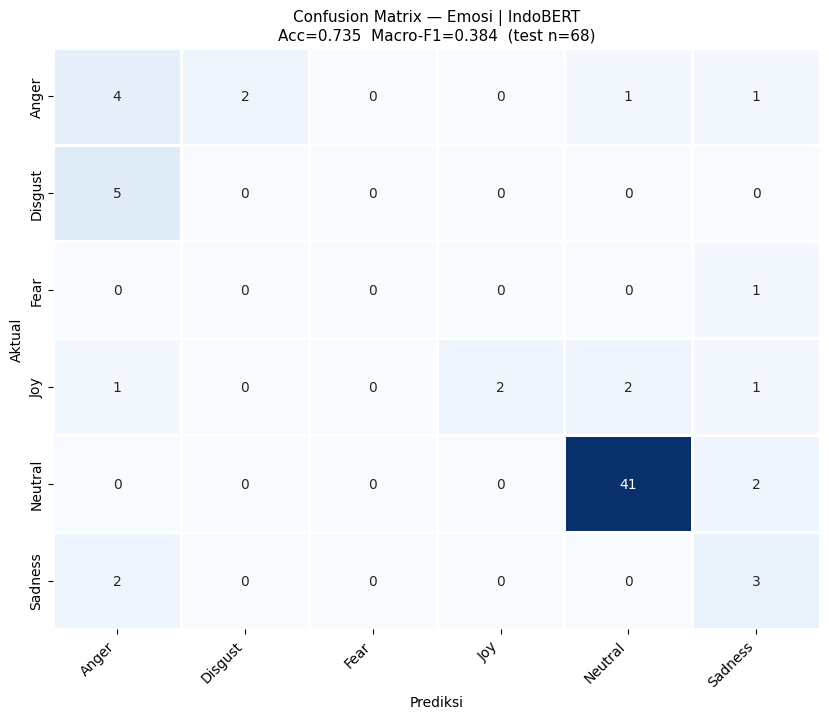

              precision    recall  f1-score   support

       Anger       0.33      0.50      0.40         8
     Disgust       0.00      0.00      0.00         5
        Fear       0.00      0.00      0.00         1
         Joy       1.00      0.33      0.50         6
     Neutral       0.93      0.95      0.94        43
     Sadness       0.38      0.60      0.46         5

    accuracy                           0.74        68
   macro avg       0.44      0.40      0.38        68
weighted avg       0.74      0.74      0.72        68



In [ ]:
CHAMPION = {}
for target in CFG["TARGETS"]:
    cands = [RESULTS[(target, k)] for k in MODEL_KEYS]
    champ = max(cands, key=lambda r: (r["f1_macro"], r["accuracy"]))
    CHAMPION[target] = champ
    dst = WORK / "models" / f"champion_{target}"
    if dst.exists(): shutil.rmtree(dst)
    shutil.copytree(WORK / "models" / target / champ["model_key"], dst)
    json.dump(dict(model=champ["model"], model_key=champ["model_key"], best_params=champ["best_params"],
                   classes=list(DATA[target]["le"].classes_),
                   **{k: champ[k] for k in ("accuracy", "precision_macro", "recall_macro", "f1_macro")}),
              open(dst / "champion_info.json", "w"), indent=2)
    print(f"Champion {target}: {champ['model']} (Macro-F1 test={champ['f1_macro']:.4f}) -> {dst}")

def plot_confusion(target, champ):
    d = DATA[target]; classes = list(d["le"].classes_); labels = np.arange(len(classes))
    cm = confusion_matrix(d["y_test"], champ["y_pred"], labels=labels)
    fig, ax = plt.subplots(figsize=(0.9 * len(classes) + 3, 0.8 * len(classes) + 2.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=2, linecolor="white",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
    ax.set_title(f"Confusion Matrix — {target.capitalize()} | {champ['model']}\n"
                 f"Acc={champ['accuracy']:.3f}  Macro-F1={champ['f1_macro']:.3f}  (test n={len(d['y_test'])})", fontsize=11)
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    out = WORK / "figures" / f"confusion_matrix_champion_{target}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
    print(classification_report(d["y_test"], champ["y_pred"], labels=labels, target_names=classes, zero_division=0))
    return out

for target, champ in CHAMPION.items():
    plot_confusion(target, champ)

## 11. Batch Inference Populasi (baris belum berlabel)
Baris yang `id`-nya **tidak** ada di sampel diprediksi memakai Champion Model. Baris sampel diisi dari
`aspek_final` / `emosi_final` (kolom `sumber_label` = `anotasi` atau `prediksi`).
Kolom `emosi` dibuat baru (di berkas populasi hanya ada kolom `aspek` yang kosong).

In [ ]:
is_labelled = df_pop[CFG["ID_COL"]].isin(df_sample[CFG["ID_COL"]])
df_unl = df_pop[~is_labelled].copy()
print(f"Populasi={len(df_pop)} | berlabel (sampel)={is_labelled.sum()} | perlu prediksi={len(df_unl)}")

X_unl = df_unl[CFG["TEXT_COL"]].fillna("").map(clean_text).tolist()
out = df_pop.copy()
out["aspek"] = out["aspek"].astype(object)
out["emosi"] = None

for target in CFG["TARGETS"]:
    model = load_any_model(WORK / "models" / f"champion_{target}")     # bukti model tersimpan bisa dimuat ulang
    pred = model.predict(X_unl)
    out.loc[df_unl.index, target] = DATA[target]["le"].inverse_transform(pred)
    del model; free_memory()

lab = df_sample.set_index(CFG["ID_COL"])
for target, col in CFG["TARGETS"].items():
    out.loc[is_labelled, target] = out.loc[is_labelled, CFG["ID_COL"]].map(lab[col])
out["sumber_label"] = np.where(is_labelled, "anotasi", "prediksi")

out.to_csv(CFG["OUTPUT_FILE"], index=False, encoding="utf-8")
print("Tersimpan:", CFG["OUTPUT_FILE"], out.shape)
print(out["sumber_label"].value_counts().to_string())
print("Nilai kosong aspek/emosi:", out[["aspek", "emosi"]].isna().sum().to_dict())
out[[CFG["ID_COL"], "aspek", "emosi", "sumber_label"]].head()

Populasi=2890 | berlabel (sampel)=340 | perlu prediksi=2550


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tersimpan: populasi_uts_final_kelarr.csv (2890, 12)
sumber_label
prediksi    2550
anotasi      340
Nilai kosong aspek/emosi: {'aspek': 0, 'emosi': 0}


,id,aspek,emosi,sumber_label
0,GEMPA_TW_000027,A1,Sadness,prediksi
1,GEMPA_TW_000039,A1,Neutral,prediksi
2,GEMPA_TW_000057,A1,Neutral,prediksi
3,GEMPA_TW_000060,A1,Sadness,prediksi
4,GEMPA_TW_000061,A1,Sadness,prediksi


## 12. Visualisasi Distribusi Prediksi (seluruh populasi, n = 2.890)

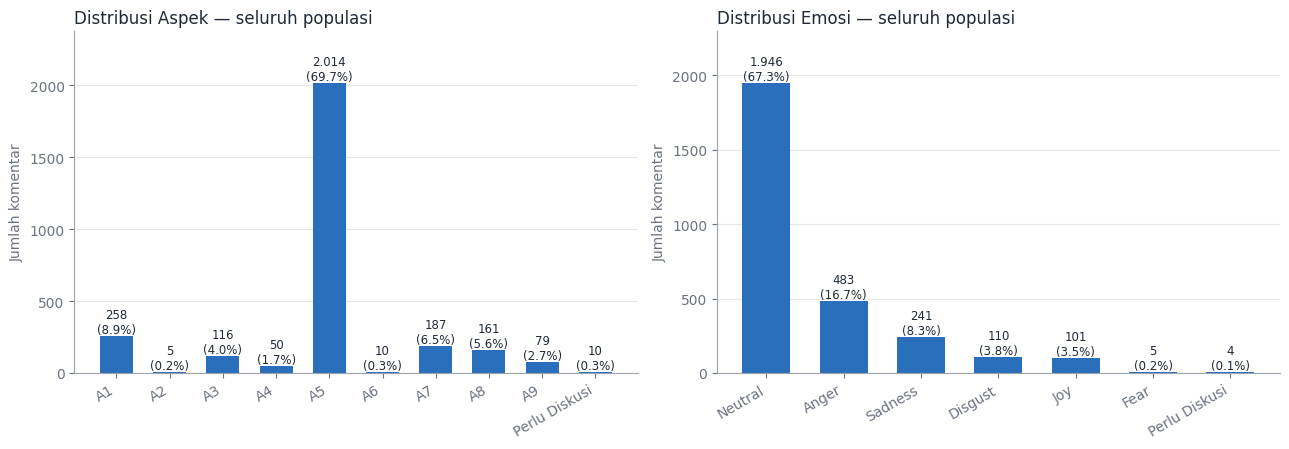

In [ ]:
INK, MUTED, BLUE = "#1F2937", "#6B7280", "#2A6FBB"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#9CA3AF", "text.color": INK, "axes.labelcolor": MUTED,
                     "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10})

def order_labels(series, by_code):
    vc = series.value_counts()
    return sorted(vc.index) if by_code else list(vc.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, col, by_code in zip(axes, ["aspek", "emosi"], [True, False]):
    order = order_labels(out[col], by_code)
    counts = out[col].value_counts().reindex(order)
    bars = ax.bar(order, counts.values, color=BLUE, width=0.62)
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v/len(out):.1%})".replace(",", "."),
                ha="center", va="bottom", fontsize=8.5, color=INK)
    ax.set_title(f"Distribusi {col.capitalize()} — seluruh populasi", loc="left", fontsize=12, color=INK)
    ax.set_ylabel("Jumlah komentar"); ax.set_ylim(0, counts.max() * 1.18)
    ax.yaxis.grid(True, color="#E5E7EB"); ax.set_axisbelow(True)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout(); fig.savefig(WORK / "figures" / "distribusi_aspek_emosi.png", dpi=200, bbox_inches="tight"); plt.show()

## 13. Heatmap Crosstab Aspek × Emosi

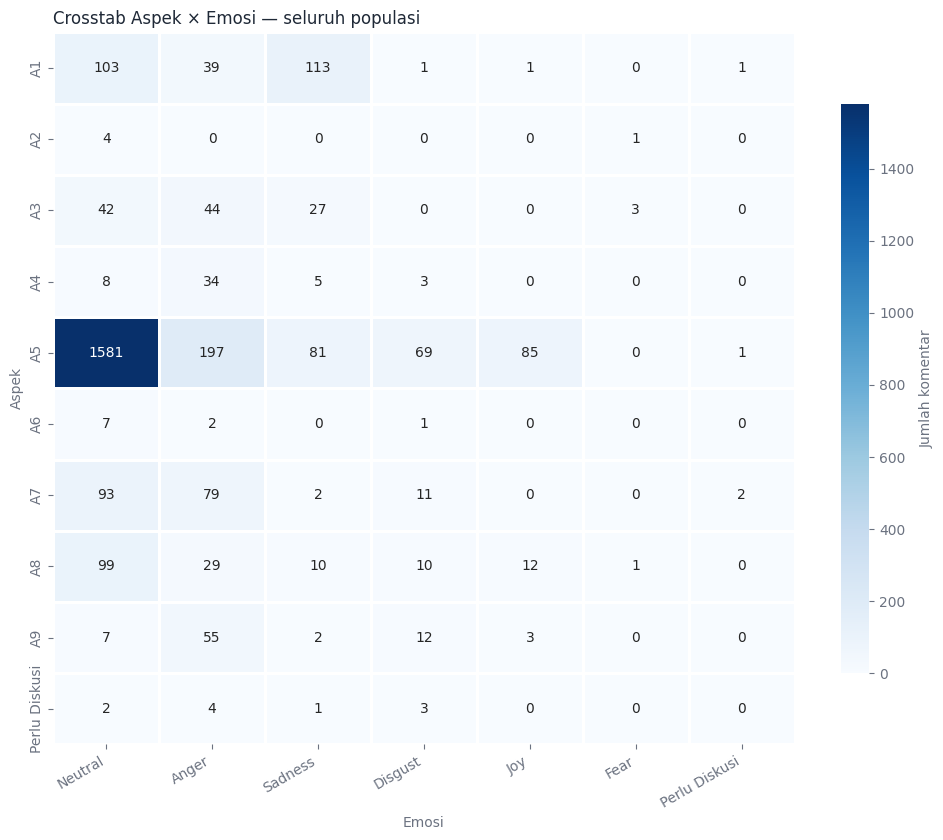

emosi,Neutral,Anger,Sadness,Disgust,Joy,Fear,Perlu Diskusi
aspek,,,,,,,
A1,103,39,113,1,1,0,1
A2,4,0,0,0,0,1,0
A3,42,44,27,0,0,3,0
A4,8,34,5,3,0,0,0
A5,1581,197,81,69,85,0,1
A6,7,2,0,1,0,0,0
A7,93,79,2,11,0,0,2
A8,99,29,10,10,12,1,0
A9,7,55,2,12,3,0,0


In [ ]:
ct = pd.crosstab(out["aspek"], out["emosi"])
ct = ct.reindex(index=sorted(ct.index), columns=list(out["emosi"].value_counts().index))
fig, ax = plt.subplots(figsize=(1.0 * ct.shape[1] + 3, 0.6 * ct.shape[0] + 2.5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", linewidths=2, linecolor="white",
            cbar_kws={"label": "Jumlah komentar", "shrink": 0.8}, ax=ax)
ax.set_xlabel("Emosi"); ax.set_ylabel("Aspek")
ax.set_title("Crosstab Aspek × Emosi — seluruh populasi", loc="left", fontsize=12, color=INK)
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
fig.savefig(WORK / "figures" / "heatmap_aspek_emosi.png", dpi=200, bbox_inches="tight"); plt.show()
ct

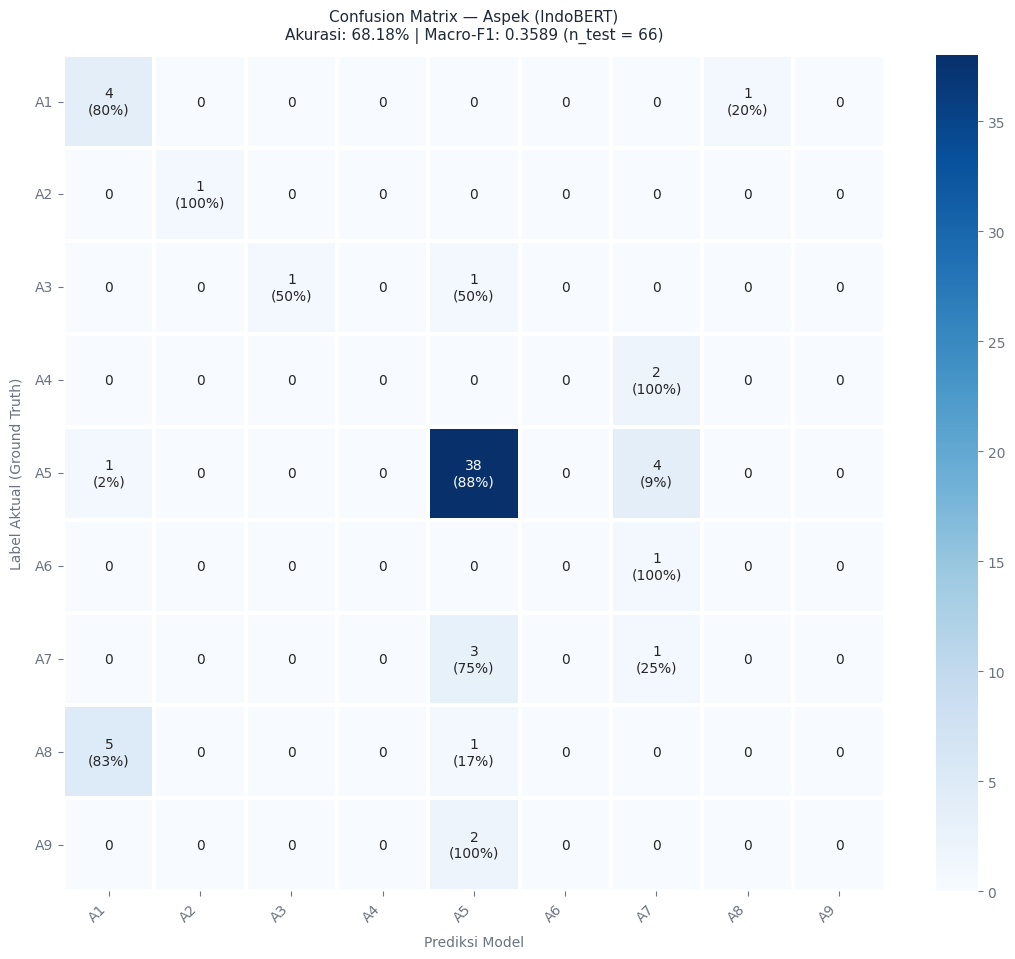

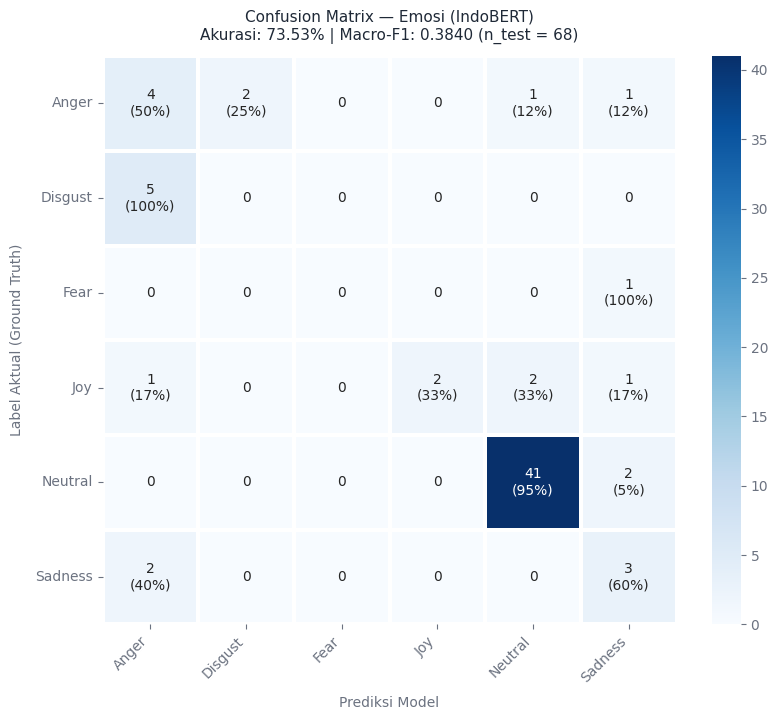


 ERROR ANALYSIS — TARGET: ASPEK
 Total Kesalahan: 21 dari 66 sampel uji (31.8%)

Top 5 Pola Kesalahan Terbanyak:
pola_error
A8 -> A1    5
A5 -> A7    4
A7 -> A5    3
A9 -> A5    2
A4 -> A7    2

 ERROR ANALYSIS — TARGET: EMOSI
 Total Kesalahan: 18 dari 68 sampel uji (26.5%)

Top 5 Pola Kesalahan Terbanyak:
pola_error
Disgust -> Anger      5
Joy -> Neutral        2
Sadness -> Anger      2
Neutral -> Sadness    2
Anger -> Disgust      2

[OK] Berkas 'error_analysis_aspek.csv' & 'error_analysis_emosi.csv' berhasil dibuat.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_styled_confusion_matrix(target_name):
    champ = CHAMPION[target_name]
    d = DATA[target_name]
    classes = list(d["le"].classes_)
    labels = np.arange(len(classes))

    cm = confusion_matrix(d["y_test"], champ["y_pred"], labels=labels)

    # Hitung persentase recall per baris (aktual)
    cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], 1)

    fig, ax = plt.subplots(figsize=(len(classes) * 0.9 + 3, len(classes) * 0.8 + 2.5))

    # Annotasi: angka absolut + persentase per baris
    annot = np.empty_like(cm).astype(str)
    for i in range(len(classes)):
        for j in range(len(classes)):
            annot[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]:.0%})" if cm[i, j] > 0 else "0"

    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=True,
                linewidths=1.5, linecolor="white",
                xticklabels=classes, yticklabels=classes, ax=ax)

    ax.set_title(f"Confusion Matrix — {target_name.capitalize()} ({champ['model']})\n"
                 f"Akurasi: {champ['accuracy']:.2%} | Macro-F1: {champ['f1_macro']:.4f} (n_test = {len(d['y_test'])})",
                 fontsize=11, pad=12)
    ax.set_xlabel("Prediksi Model", fontsize=10, labelpad=8)
    ax.set_ylabel("Label Aktual (Ground Truth)", fontsize=10, labelpad=8)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Tampilkan untuk kedua target
for target in ["aspek", "emosi"]:
    plot_styled_confusion_matrix(target)


def get_error_analysis_table(target_name):
    champ = CHAMPION[target_name]
    d = DATA[target_name]
    le = d["le"]

    y_true = np.array(d["y_test"])
    y_pred = np.array(champ["y_pred"])

    # Ambil index data uji yang salah diprediksi
    error_mask = (y_true != y_pred)

    df_errors = pd.DataFrame({
        "id": d["ids_test"][error_mask],
        "komentar_clean": d["X_test"][error_mask],
        "aktual": le.inverse_transform(y_true[error_mask]),
        "prediksi": le.inverse_transform(y_pred[error_mask])
    })

    df_errors["pola_error"] = df_errors["aktual"] + " -> " + df_errors["prediksi"]

    print("\n" + "=" * 55)
    print(f" ERROR ANALYSIS — TARGET: {target_name.upper()}")
    print(f" Total Kesalahan: {len(df_errors)} dari {len(y_true)} sampel uji ({len(df_errors)/len(y_true):.1%})")
    print("=" * 55)

    print("\nTop 5 Pola Kesalahan Terbanyak:")
    print(df_errors["pola_error"].value_counts().head(5).to_string())

    return df_errors

df_error_aspek = get_error_analysis_table("aspek")
df_error_emosi = get_error_analysis_table("emosi")

df_error_aspek.to_csv("error_analysis_aspek.csv", index=False)
df_error_emosi.to_csv("error_analysis_emosi.csv", index=False)
print("\n[OK] Berkas 'error_analysis_aspek.csv' & 'error_analysis_emosi.csv' berhasil dibuat.")

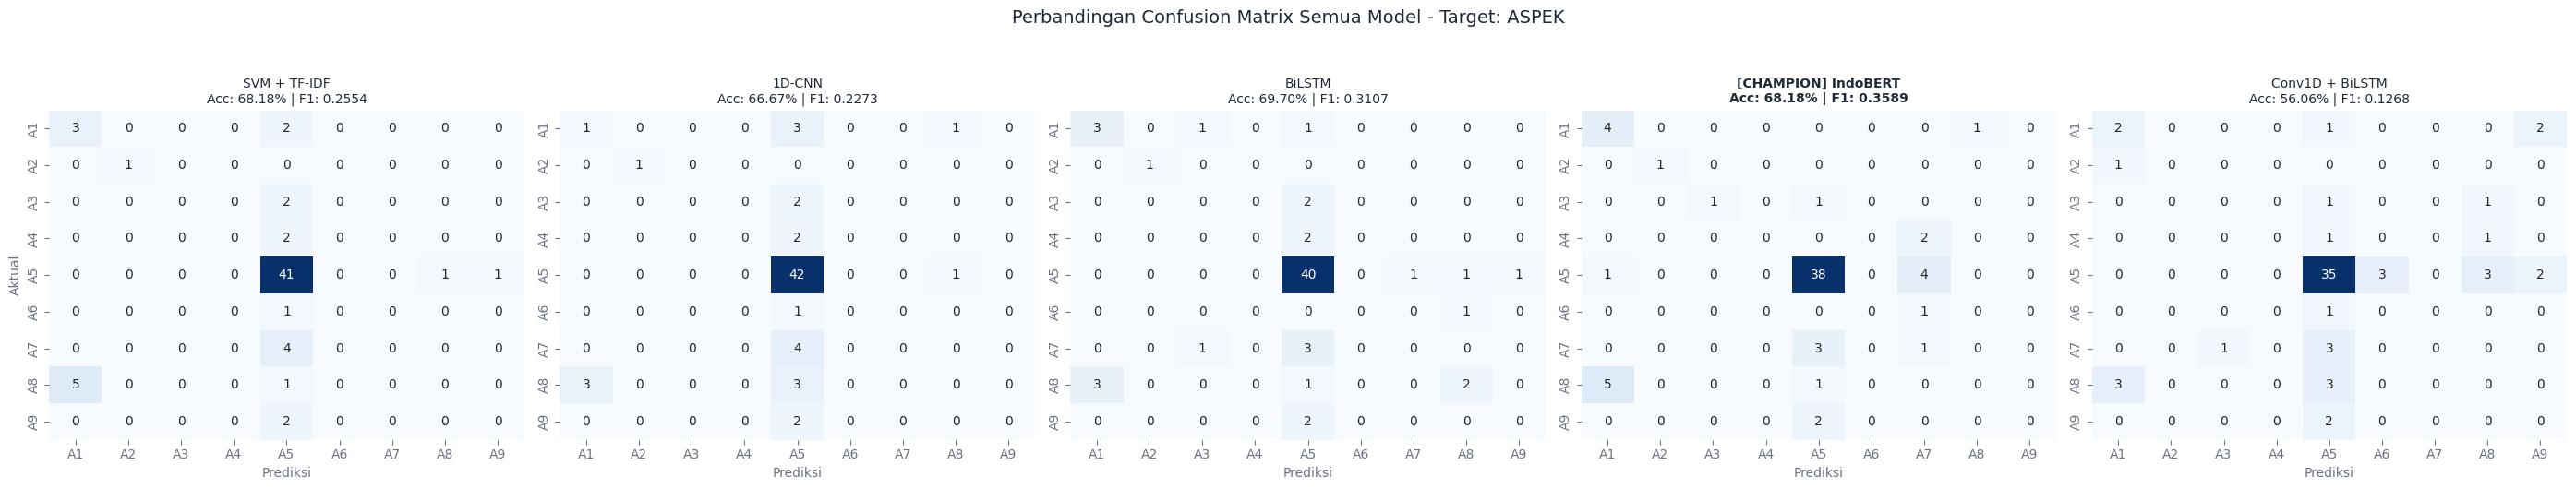

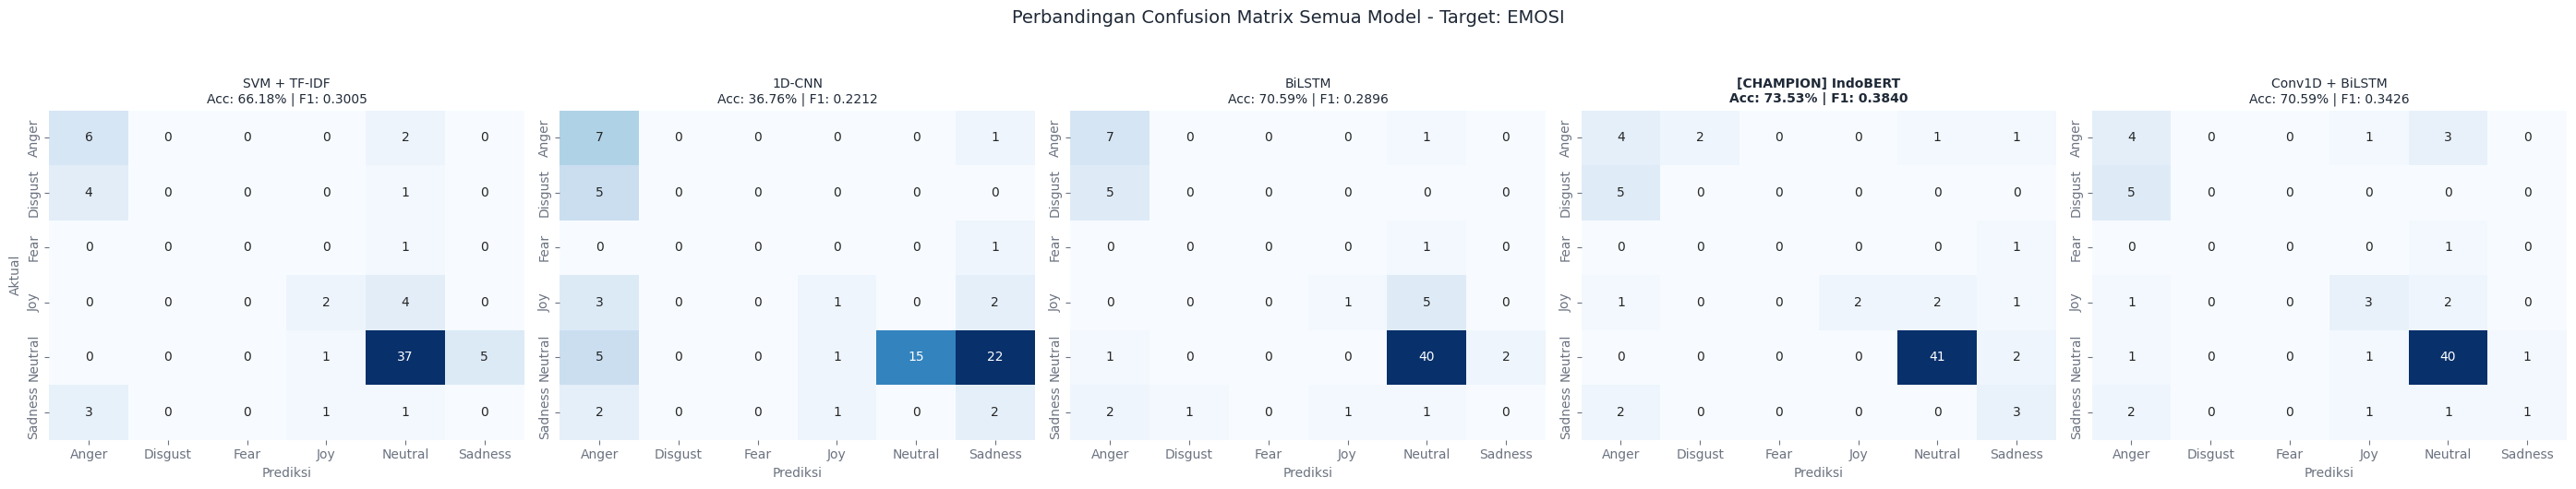

In [ ]:
def plot_all_confusion_matrices(target_name):
    d = DATA[target_name]
    classes = list(d["le"].classes_)
    labels = np.arange(len(classes))

    fig, axes = plt.subplots(1, 5, figsize=(28, 5))

    for idx, key in enumerate(MODEL_KEYS):
        r = RESULTS[(target_name, key)]
        cm = confusion_matrix(d["y_test"], r["y_pred"], labels=labels)

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=classes, yticklabels=classes, ax=axes[idx])

        is_champ = (key == CHAMPION[target_name]["model_key"])
        title_prefix = "[CHAMPION] " if is_champ else ""
        axes[idx].set_title(f"{title_prefix}{MODEL_NAMES[key]}\nAcc: {r['accuracy']:.2%} | F1: {r['f1_macro']:.4f}",
                            fontsize=10, fontweight="bold" if is_champ else "normal")
        axes[idx].set_xlabel("Prediksi")
        if idx == 0:
            axes[idx].set_ylabel("Aktual")
        else:
            axes[idx].set_ylabel("")

    plt.suptitle(f"Perbandingan Confusion Matrix Semua Model - Target: {target_name.upper()}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

plot_all_confusion_matrices("aspek")
plot_all_confusion_matrices("emosi")

In [ ]:
# ===== TAMBAHAN E — Peringkat model: validasi vs test (hanya ditampilkan, CHAMPION tidak diubah) =====
for target in CFG["TARGETS"]:
    t = pd.DataFrame([{"Model": RESULTS[(target, k)]["model"],
                       "Val Macro-F1": RESULTS[(target, k)]["val_f1_macro"],
                       "Test Macro-F1": RESULTS[(target, k)]["f1_macro"]} for k in MODEL_KEYS])
    t["Peringkat (val)"] = t["Val Macro-F1"].rank(ascending=False, method="min").astype(int)
    t["Peringkat (test)"] = t["Test Macro-F1"].rank(ascending=False, method="min").astype(int)
    print(f"\n=== {target.upper()} | champion notebook: {CHAMPION[target]['model']} ===")
    display(t.sort_values("Peringkat (val)").round(3).reset_index(drop=True))
    terbaik_val = t.loc[t["Val Macro-F1"].idxmax(), "Model"]
    if terbaik_val != CHAMPION[target]["model"]:
        print(f"Catatan: model terbaik menurut validasi adalah {terbaik_val}, berbeda dengan champion (dipilih dari test).")


=== ASPEK | champion notebook: IndoBERT ===


,Model,Val Macro-F1,Test Macro-F1,Peringkat (val),Peringkat (test)
0,IndoBERT,0.406,0.359,1,1
1,BiLSTM,0.365,0.311,2,2
2,SVM + TF-IDF,0.314,0.255,3,3
3,Conv1D + BiLSTM,0.276,0.127,4,5
4,1D-CNN,0.272,0.227,5,4



=== EMOSI | champion notebook: IndoBERT ===


,Model,Val Macro-F1,Test Macro-F1,Peringkat (val),Peringkat (test)
0,IndoBERT,0.675,0.384,1,1
1,SVM + TF-IDF,0.488,0.300,2,3
2,BiLSTM,0.463,0.290,3,4
3,1D-CNN,0.400,0.221,4,5
4,Conv1D + BiLSTM,0.373,0.343,5,2


## 14. (Opsional) Unduh hasil dari Colab

In [ ]:
 from google.colab import files
 shutil.make_archive("hasil_klasifikasi", "zip", WORK)         # model, metrik, gambar
 files.download("hasil_klasifikasi.zip"); files.download(CFG["OUTPUT_FILE"])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>